# Heat Flux Interpolation Example

This notebook demonstrates interpolating scalar heat flux values from source to destination mesh using the AVERAGE kernel with k=3 nearest neighbors.

In [1]:
from interpcore.interpolator import Interpolator
from interpcore.config import InterpolationConfig, QUERY_TYPE, INTERPOLATED_LOAD_TYPE
from interpcore.kernels import INTERPOLATION_KERNEL

c:\ProgramData\anaconda3\envs\interpcore\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configure and Run Interpolation

In [ ]:
# Create configuration for AVERAGE kernel with HEAT_FLUX load type
config = InterpolationConfig(
    method=QUERY_TYPE.K,
    param=3,
    max_distance=2.0,
    coincidence_tolerance=0.01,
    kernel=INTERPOLATION_KERNEL.AVERAGE,
    multithread=False,
    interpolated_load=INTERPOLATED_LOAD_TYPE.HEAT_FLUX
)

# Define file column indices (including area column for integral computation)
file_idx = {"ids": 0, "dest_x": 1, "src_x": 1, "val": 4, "area": 4}

# Create interpolator
interpolator = Interpolator(
    path_to_src_folder="source_data",
    path_to_dest_mesh="destination_mesh.txt",
    config=config,
    file_idx=file_idx
)

# Run interpolation
interpolator.interpolate_all()
print("Interpolation completed!")

100%|██████████| 1/1 [00:00<00:00, 13.76it/s]

Interpolation completed!


## Export to APDL format

In [3]:
from tempfile import TemporaryDirectory

with TemporaryDirectory() as tmp_dir:
    interpolator.export_to_ansys(tmp_dir)  # the export command

    # Preview the exported file content
    with open(f"{tmp_dir}/interpolated_heat_flux_data.txt", "r") as f:
        for line in f.readlines()[:5]:
            print(line.strip())

SFE, 101.0,, HFLUX,, 124.92999999999999
SFE, 102.0,, HFLUX,, 124.92999999999999
SFE, 103.0,, HFLUX,, 130.0
SFE, 104.0,, HFLUX,, 160.0
SFE, 105.0,, HFLUX,, 184.1966666666667


## View Results

It is possible to expore the interpolated results producing vtk files. These can be either visualized directly using pyvista or exported to .vtk to be further processed later in paraview.

In [4]:
import pyvista as pv
import matplotlib.pyplot as plt

interpolator.build_vtk_output(outdir=None) # set to an existing path to export vtk files

This is just a bunch of boiler plate code to plot this direclty in the jupyter

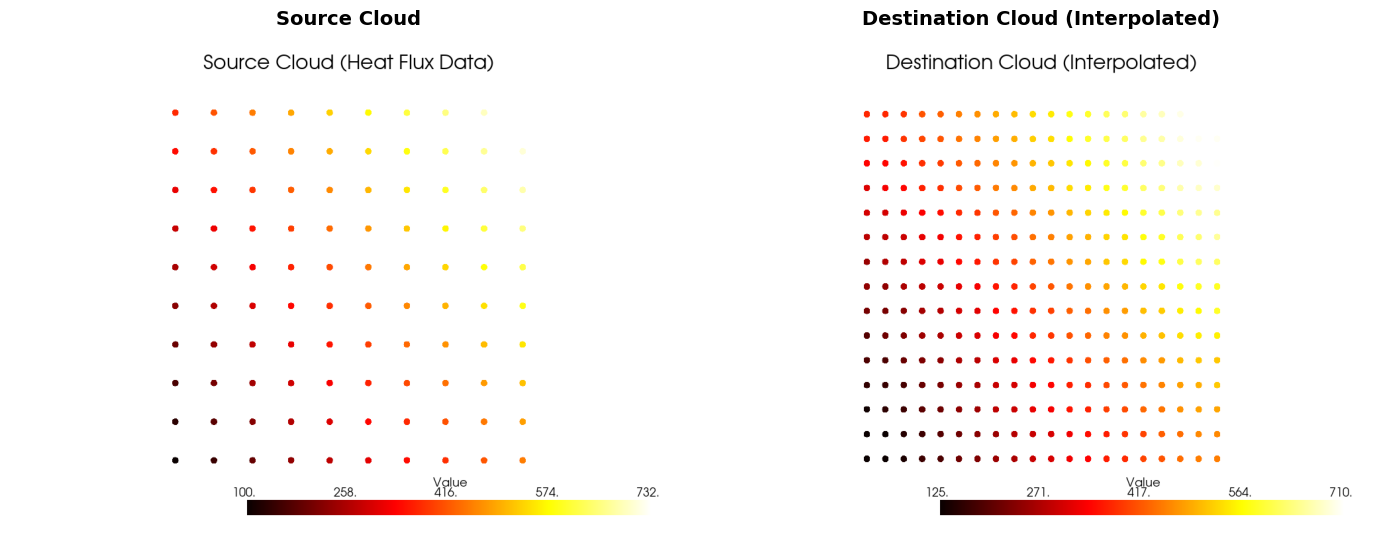

In [5]:
source_cloud = interpolator.src_vtk["heat_flux_data"]
dest_cloud = interpolator.dest_vtk["heat_flux_data"]

# Create a static plot comparing the two clouds side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot source cloud with gaussian points
plotter_src = pv.Plotter(off_screen=True)
plotter_src.add_mesh(source_cloud, scalars='Value', cmap='hot', point_size=10, 
                     render_points_as_spheres=False, style='points')
plotter_src.add_title('Source Cloud (Heat Flux Data)', font_size=12)
plotter_src.camera_position = 'xy'
img_src = plotter_src.screenshot(return_img=True)
plotter_src.close()

# Plot destination cloud with gaussian points
plotter_dest = pv.Plotter(off_screen=True)
plotter_dest.add_mesh(dest_cloud, scalars='Value', cmap='hot', point_size=10, 
                      render_points_as_spheres=False, style='points')
plotter_dest.add_title('Destination Cloud (Interpolated)', font_size=12)
plotter_dest.camera_position = 'xy'
img_dest = plotter_dest.screenshot(return_img=True)
plotter_dest.close()

# Display in matplotlib
axes[0].imshow(img_src)
axes[0].axis('off')
axes[0].set_title('Source Cloud', fontsize=14, fontweight='bold')

axes[1].imshow(img_dest)
axes[1].axis('off')
axes[1].set_title('Destination Cloud (Interpolated)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Compute Total Heat Flux Integral

Calculate the total heat flux over the destination surface by integrating the scalar field.

In [ ]:
# Compute the total heat flux integral over the surface area
integrals = interpolator.compute_scalar_integrals()

print(f"{'='*60}")
print("Total Heat Flux Integrals")
print(f"{'='*60}")
for name, integral in integrals.items():
    print(f"\n{name}: {integral[0]:.6f} W (or units of heat_flux * area)")